# ERK Pathway — Simulation

Tests the full pipeline:
- 20 000 passenger mutations + 10 ERK drivers (3× BRAF GOF, 2× NRAS GOF, 5× NF1 LOF)
- `UniformMutationGenerator` samples from the full store (μ = 2 per division)
- `ErkPathwayPlugin` scores each cell via formula 2.8 and drives proliferation
- `GillespieEngine` + `Recorder` log every event and periodic snapshots
- 10 founder cells to avoid early stochastic extinction

In [1]:
import sys
sys.path.insert(0, "..")

import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from tqdm.notebook import tqdm

from evoseer.core.config import PluginConfig, RateFunctionConfig, SimulationConfig
from evoseer.engine.gillespie import GillespieEngine
from evoseer.plugins.mutation_rate import ConstantMutationRatePlugin
from evoseer.plugins.pathway.erk import ErkPathwayPlugin
from evoseer.rate_functions.weighted_sum import WeightedSumRate
from evoseer.recording.recorder import Recorder
from evoseer.services.mutation_generator import UniformMutationGenerator
from evoseer.services.mutation_store import InMemoryMutationStore, MutationRecord

## 1. Mutation store

20 000 passenger mutations + 10 ERK drivers + 1 density-regulation mutation.

The regulation mutation (`DENSITY_MUT_ID`) carries `extra={"d": 0.001}` and is assigned
to every founder cell. Combined with `alpha=1` on the death plugin, it produces a logistic
carrying capacity **K ≈ (b − baseline_death) / d_coeff ≈ (0.63 − 0.2) / 0.001 ≈ 430**.

In [2]:
N_PASS = 20_000
DENSITY_MUT_ID = 20_010   # regulation mutation assigned to all founders

# (mut_id, gene_id, gene_name, effect, label)
DRIVER_DEFS = [
    (N_PASS + 0, 673,  "BRAF", "GOF", "BRAF GOF #1"),
#    (N_PASS + 1, 673,  "BRAF", "GOF", "BRAF GOF #2"),
#     (N_PASS + 2, 673,  "BRAF", "GOF", "BRAF GOF #3"),
     (N_PASS + 3, 4893, "NRAS", "GOF", "NRAS GOF #1"),
#     (N_PASS + 4, 4893, "NRAS", "GOF", "NRAS GOF #2"),
#     (N_PASS + 5, 4763, "NF1",  "LOF", "NF1 LOF #1"),
#     (N_PASS + 6, 4763, "NF1",  "LOF", "NF1 LOF #2"),
#     (N_PASS + 7, 4763, "NF1",  "LOF", "NF1 LOF #3"),
#     (N_PASS + 8, 4763, "NF1",  "LOF", "NF1 LOF #4"),
#     (N_PASS + 9, 4763, "NF1",  "LOF", "NF1 LOF #5"),
 ]

DRIVER_LABEL = {d[0]: d[4] for d in DRIVER_DEFS}
GENE_COLOR   = {673: "#4C9BE8", 4893: "#2E7D32", 4763: "#F4A261"}  # BRAF/NRAS/NF1
DRIVER_COLOR = {d[0]: GENE_COLOR[d[1]] for d in DRIVER_DEFS}

def build_store() -> InMemoryMutationStore:
    store = InMemoryMutationStore()
    for i in range(N_PASS):
        store.add_mutation(MutationRecord(mutation_id=i, is_driver=False, extra={"d": 0.01}))
    for mut_id, gene_id, gene_name, effect, _ in DRIVER_DEFS:
        store.add_mutation(MutationRecord(
            mutation_id=mut_id,
            gene_id=gene_id,
            gene_name=gene_name,
            pathways=["ERK"],
            is_driver=True,
            effect=effect,
        ))
    return store

store = build_store()
print(f"{len(store.all_ids())} mutations total — {N_PASS} passengers, {len(DRIVER_DEFS)} drivers, 1 regulation")
print(f"Driver IDs   : {[d[0] for d in DRIVER_DEFS]}")
print(f"Regulation ID: {DENSITY_MUT_ID}  (d_coeff=0.001, K≈430)")

20002 mutations total — 20000 passengers, 2 drivers, 1 regulation
Driver IDs   : [20000, 20003]
Regulation ID: 20010  (d_coeff=0.001, K≈430)


## 2. Engine setup

**Plugins**
- `ErkPathwayPlugin` → `rate_function / proliferative` (weight = 0.5): score P_R ∈ (0,1) boosts birth rate
- `DeathRatePlugin` → `rate_function / deleterious` (weight = 1, **α = 1**): reads `d` from mutation `extra`, density-dependent death
- `ConstantMutationRatePlugin` → `mutation_rate` (μ = 2)

**Rates (WeightedSumRate)**
```
b_i = 0.50 + 0.5 × P_R
d_i = 0.20 + 1.0 × Σ(d_mut) × N¹
```
At plateau (N = K): b = d → K ≈ (0.63 − 0.20) / 0.001 ≈ **430 cells**

In [9]:
from evoseer.core.cell import CellState
from evoseer.core.context import SimContext
from evoseer.plugins.dummies import DummyDeathPlugin


N_FOUNDERS = 10

def build_engine(store, seed=42, max_steps=10_000, max_cells=2_000):
    plugins = {
        "erk_pathway":          ErkPathwayPlugin(params={}, store=store),
        "density_death":        DummyDeathPlugin(params={}, store=store),
        "constant_mutation_rate": ConstantMutationRatePlugin(params={"mu": 2.0}, store=store),
    }
    plugin_configs = {
        "erk_pathway": PluginConfig(
            name="erk_pathway", plugin_type="erk_pathway",
            target="rate_function", category="proliferative",
            weight=5, alpha=1,
        ),
        "density_death": PluginConfig(
            name="density_death", plugin_type="density_death",
            target="rate_function", category="deleterious",
            weight=1.0, alpha=1.0,   # d_i += score × N¹
        ),
        "constant_mutation_rate": PluginConfig(
            name="constant_mutation_rate", plugin_type="constant_mutation_rate",
            target="mutation_rate",
            weight=1.0, alpha=0.0,
        ),
    }
    rate_fn = WeightedSumRate(RateFunctionConfig(
        baseline_birth_rate=1,
        baseline_death_rate=0,
    ))
    return GillespieEngine(
        plugins=plugins,
        plugin_configs=plugin_configs,
        rate_function=rate_fn,
        mutation_generator=UniformMutationGenerator(store, params={"seed": seed}),
        store=store,
        recorder=Recorder(snapshot_interval=100, dump_final_state=True),
        config=SimulationConfig(
            max_steps=max_steps, max_time=1e9, max_cells=max_cells, seed=seed
        ),
    )


def make_founders(engine):
    founders = [engine.make_founder_cell() for _ in range(N_FOUNDERS)]
    for f in founders:
        f.state.mutations.add(DENSITY_MUT_ID)
    return founders

## 3. Single run

In [11]:
engine = build_engine(store, seed=5, max_cells=10000)
result = engine.run(make_founders(engine))

snap = result.snapshots
print(f"Stop      : {result.stop_reason}")
print(f"Final N   : {snap[-1].n_alive if snap else 0}")
print(f"Divisions : {len(result.divisions)}  Deaths: {len(result.deaths)}")
print(f"Drivers   : {len(result.drivers)}")
print()
for ev in result.drivers:
    label = DRIVER_LABEL.get(ev.mutation_id, f"mut_{ev.mutation_id}")
    print(f"  step {ev.step:5d}  cell {ev.cell_id:4d}  {label}")

Stop      : max_steps
Final N   : 8724
Divisions : 9357  Deaths: 643
Drivers   : 3

  step   709  cell  675  NRAS GOF #1
  step   717  cell  682  BRAF GOF #1
  step  3281  cell 3059  NRAS GOF #1


In [ ]:
from evoseer.recording.exporter import SimulationExporter

exporter = SimulationExporter(result, store=engine._store, config=engine._config)
exporter.save("test.evoseer.json")

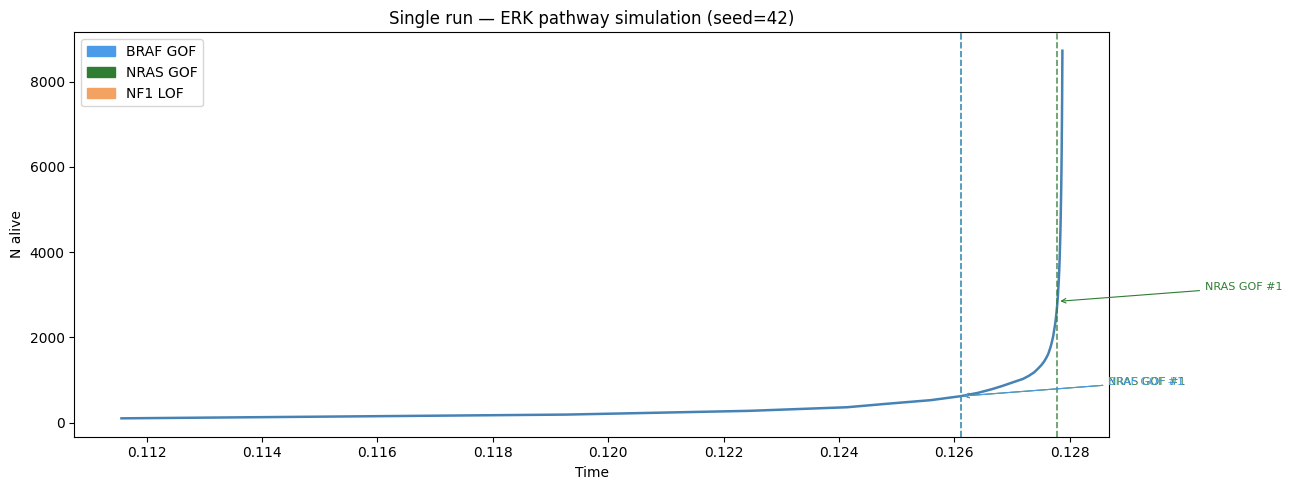

In [12]:
times   = [s.t       for s in result.snapshots]
n_alive = [s.n_alive for s in result.snapshots]

# Map step → time for driver event markers (snapshots every 100 steps)
step_to_time = {s.step: s.t for s in result.snapshots}
snap_steps   = sorted(step_to_time)

def driver_time(ev_step):
    nearest = min(snap_steps, key=lambda s: abs(s - ev_step))
    return step_to_time[nearest]

fig, ax = plt.subplots(figsize=(13, 5))
ax.plot(times, n_alive, color="steelblue", linewidth=1.8, label="N alive")

for ev in result.drivers:
    t_ev  = driver_time(ev.step)
    color = DRIVER_COLOR.get(ev.mutation_id, "gray")
    label = DRIVER_LABEL.get(ev.mutation_id, "?")
    ax.axvline(t_ev, color=color, linewidth=1.2, linestyle="--", alpha=0.8)
    idx = min(range(len(times)), key=lambda i: abs(times[i] - t_ev))
    ax.annotate(label, xy=(t_ev, n_alive[idx]),
                xytext=(t_ev + max(times) * 0.02, n_alive[idx] + max(n_alive) * 0.03),
                fontsize=8, color=color,
                arrowprops=dict(arrowstyle="->", color=color, lw=0.8))

legend_patches = [
    mpatches.Patch(color="#4C9BE8", label="BRAF GOF"),
    mpatches.Patch(color="#2E7D32", label="NRAS GOF"),
    mpatches.Patch(color="#F4A261", label="NF1 LOF"),
]
ax.legend(handles=legend_patches, loc="upper left")
ax.set_xlabel("Time"); ax.set_ylabel("N alive")
ax.set_title("Single run — ERK pathway simulation (seed=42)")
plt.tight_layout(); plt.show()

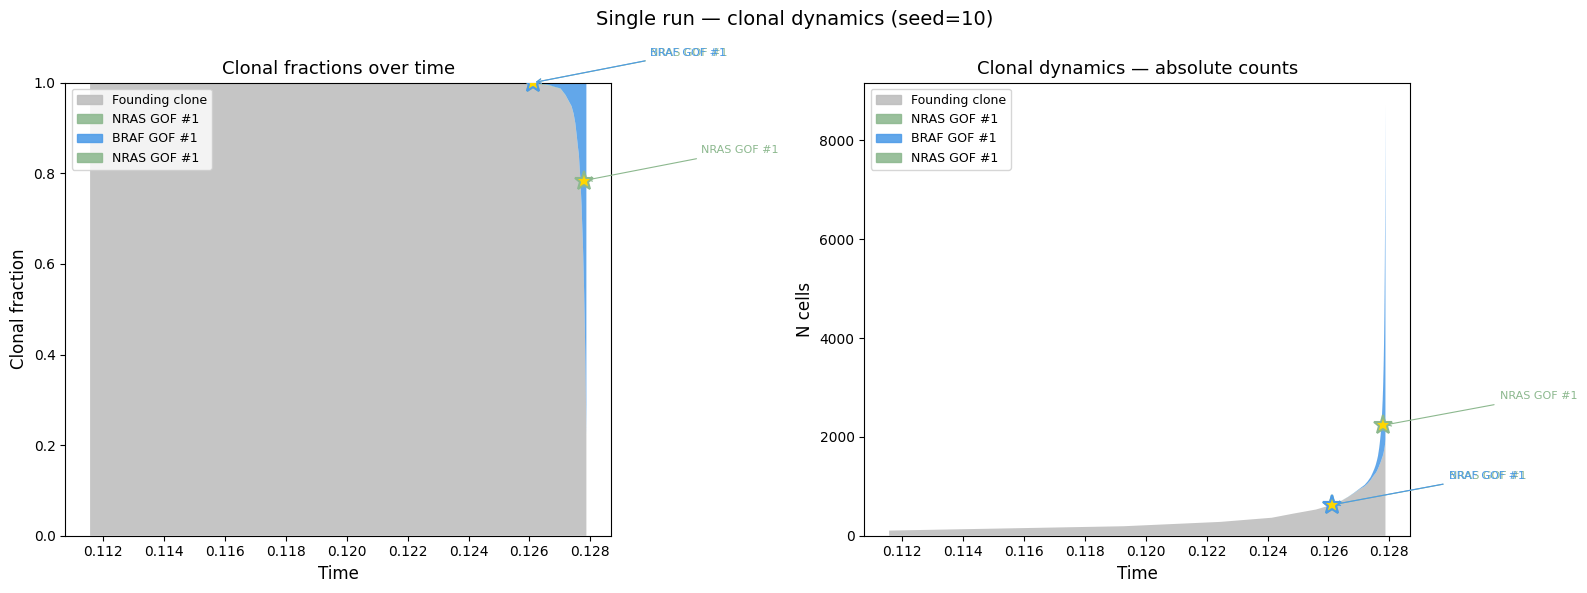

In [13]:
# ── Fishplot: clonal fractions and absolute counts (single run) ─────────────
from collections import defaultdict

# ── 1. Reconstruct per-snapshot clone sizes from lineage events ──────────────
div_by_step    = defaultdict(list)
death_by_step  = defaultdict(list)
driver_by_step = defaultdict(list)

for ev in result.divisions: div_by_step[ev.step].append(ev.child_id)
for ev in result.deaths:    death_by_step[ev.step].append(ev.cell_id)
for ev in result.drivers:   driver_by_step[ev.step].append((ev.cell_id, ev.mutation_id))

child_to_parent = {ev.child_id: ev.parent_id for ev in result.divisions}

# Founders = parents that were never born as a child
founder_ids = set(child_to_parent.values()) - set(child_to_parent.keys())

cell_drivers: dict = {fid: set() for fid in founder_ids}
alive_cells  = set(founder_ids)

# Driver mutations ordered by acquisition time → defines clone stacking order
driver_acq_order = [ev.mutation_id for ev in sorted(result.drivers, key=lambda e: e.step)]

snap_times  = []
snap_counts = []   # list of dicts {clone_key: n}  (None = founding / WT clone)

cur_step = 0
for snap in sorted(result.snapshots, key=lambda s: s.step):
    while cur_step <= snap.step:
        for cid in div_by_step.get(cur_step, []):
            cell_drivers[cid] = set(cell_drivers.get(child_to_parent[cid], set()))
            alive_cells.add(cid)
        for cid in death_by_step.get(cur_step, []):
            alive_cells.discard(cid)
        for (cid, mid) in driver_by_step.get(cur_step, []):
            if cid in cell_drivers:
                cell_drivers[cid].add(mid)
        cur_step += 1

    counts = defaultdict(int)
    for cid in alive_cells:
        cell_d = cell_drivers.get(cid, set())
        # Cell belongs to the earliest-acquired driver clone it carries
        for d in driver_acq_order:
            if d in cell_d:
                counts[d] += 1
                break
        else:
            counts[None] += 1   # no driver → founding clone
    snap_counts.append(dict(counts))
    snap_times.append(snap.t)

# ── 2. Stacked arrays ────────────────────────────────────────────────────────
stack_keys = [None] + driver_acq_order   # bottom → top

# Distinct shades for same-gene drivers
_base_gene_colors = {mid: DRIVER_COLOR[mid] for mid in driver_acq_order}
_seen_gene: dict = {}
_lightened: dict = {}
for mid in driver_acq_order:
    gene_id = store.get(mid).gene_id
    idx = _seen_gene.get(gene_id, 0)
    _seen_gene[gene_id] = idx + 1
    if idx == 0:
        _lightened[mid] = DRIVER_COLOR[mid]
    else:
        import matplotlib.colors as mc
        rgb = mc.to_rgb(DRIVER_COLOR[mid])
        # lighten by blending toward white
        factor = 0.45 * idx
        _lightened[mid] = tuple(c + (1 - c) * factor for c in rgb)

FISH_COLORS  = {None: "#BDBDBD"} | _lightened
CLONE_LABELS = {None: "Founding clone"} | {mid: DRIVER_LABEL[mid] for mid in driver_acq_order}

t_arr  = np.array(snap_times)
n_arr  = {k: np.array([sc.get(k, 0) for sc in snap_counts], dtype=float) for k in stack_keys}
total  = sum(n_arr[k] for k in stack_keys)
f_arr  = {k: n_arr[k] / np.maximum(total, 1) for k in stack_keys}

# ── 3. Plot ──────────────────────────────────────────────────────────────────
fig, (ax_f, ax_n) = plt.subplots(1, 2, figsize=(16, 6))

for ax, arrays, ylabel, title in [
    (ax_f, f_arr, "Clonal fraction",  "Clonal fractions over time"),
    (ax_n, n_arr, "N cells",          "Clonal dynamics — absolute counts"),
]:
    ys     = [arrays[k] for k in stack_keys]
    colors = [FISH_COLORS[k] for k in stack_keys]
    ax.stackplot(t_arr, ys, colors=colors, alpha=0.88)
    ax.set_xlabel("Time", fontsize=12)
    ax.set_ylabel(ylabel, fontsize=12)
    ax.set_title(title, fontsize=13)

    # Pre-compute cumulative layers for star placement
    cumul = np.zeros(len(t_arr))
    cum_layers = {}
    for k in stack_keys:
        cumul = cumul + arrays[k]
        cum_layers[k] = cumul.copy()

    for ev in sorted(result.drivers, key=lambda e: e.step):
        mid   = ev.mutation_id
        t_ev  = driver_time(ev.step)
        color = FISH_COLORS.get(mid, "gray")
        label = DRIVER_LABEL.get(mid, "?")
        ki    = stack_keys.index(mid)

        idx    = min(range(len(t_arr)), key=lambda i: abs(t_arr[i] - t_ev))
        y_bot  = cum_layers[stack_keys[ki - 1]][idx] if ki > 0 else 0.0
        y_top  = cum_layers[mid][idx]
        y_star = (y_bot + y_top) / 2 if y_top > y_bot else y_bot

        ax.plot(t_ev, y_star, "*", markersize=14,
                color="gold", markeredgecolor=color, markeredgewidth=1.5, zorder=5)

        y_max = float(np.max(list(total))) if ylabel == "N cells" else 1.0
        ax.annotate(
            label,
            xy=(t_ev, y_star),
            xytext=(t_ev + t_arr[-1] * 0.03, y_star + y_max * 0.06),
            fontsize=8, color=color,
            arrowprops=dict(arrowstyle="->", color=color, lw=0.8),
        )

patches = [mpatches.Patch(color=FISH_COLORS[k], label=CLONE_LABELS[k], alpha=0.88)
           for k in stack_keys]
ax_f.legend(handles=patches, loc="upper left", fontsize=9)
ax_n.legend(handles=patches, loc="upper left", fontsize=9)
ax_f.set_ylim(0, 1)

plt.suptitle("Single run — clonal dynamics (seed=10)", fontsize=14)
plt.tight_layout()
plt.show()

## 4. Multiple runs — stochastic variability

In [14]:
N_RUNS = 50

results = []
for seed in tqdm(range(N_RUNS)):
    eng = build_engine(store, seed=seed)
    results.append(eng.run(make_founders(eng)))

stop_counts = {}
for r in results:
    stop_counts[r.stop_reason] = stop_counts.get(r.stop_reason, 0) + 1
print("Stop reasons:", stop_counts)
driver_counts = [len(r.drivers) for r in results]
print(f"Driver events/run — mean: {np.mean(driver_counts):.1f}  max: {max(driver_counts)}  runs with 0: {driver_counts.count(0)}")

  0%|          | 0/50 [00:00<?, ?it/s]

Stop reasons: {'max_cells': 50}
Driver events/run — mean: 0.4  max: 3  runs with 0: 36


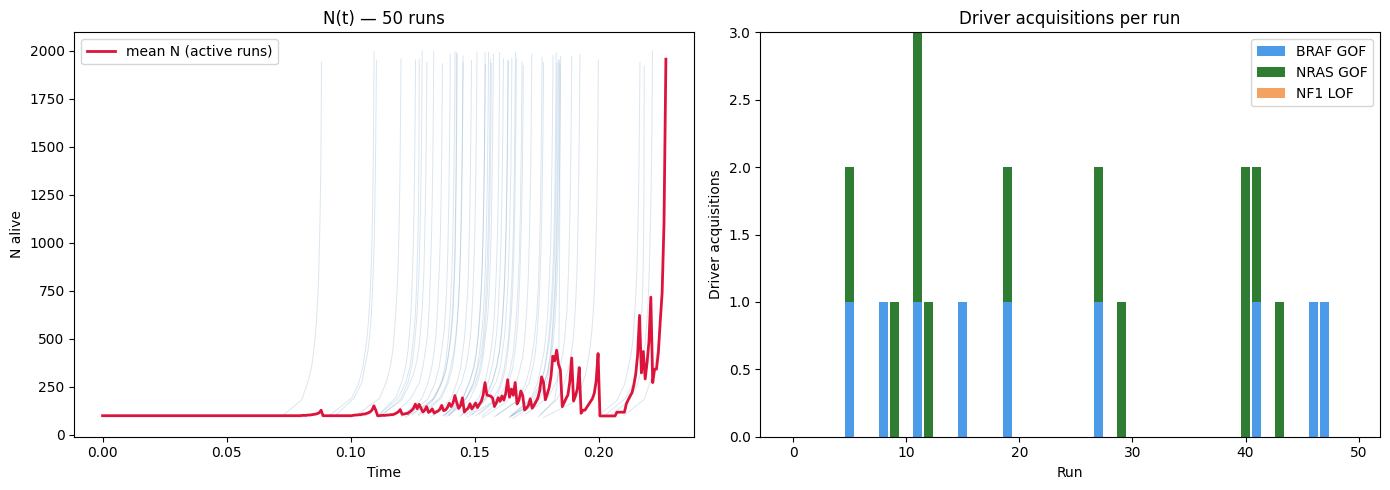

In [15]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# --- left: N(t) trajectories ---
ax = axes[0]
all_times = [[s.t       for s in r.snapshots] for r in results]
all_n     = [[s.n_alive for s in r.snapshots] for r in results]

for t_i, n_i in zip(all_times, all_n):
    ax.plot(t_i, n_i, color="steelblue", alpha=0.2, linewidth=0.7)

# Mean N over time (pad extinct runs with 0)
t_max  = max(t[-1] for t in all_times if t)
t_grid = np.linspace(0, t_max, 300)
mean_n = []
for t_val in t_grid:
    vals = [
        n_i[max(0, np.searchsorted(t_i, t_val, side="right") - 1)]
        for t_i, n_i in zip(all_times, all_n)
        if t_i and t_val <= t_i[-1]
    ]
    mean_n.append(np.mean(vals) if vals else 0.0)

ax.plot(t_grid, mean_n, color="crimson", linewidth=2, label="mean N (active runs)")
ax.set_xlabel("Time"); ax.set_ylabel("N alive")
ax.set_title(f"N(t) — {N_RUNS} runs"); ax.legend()

# --- right: driver acquisitions per run (stacked bar by gene) ---
ax = axes[1]
gene_counts = {673: [], 4893: [], 4763: []}
for r in results:
    cnt = {673: 0, 4893: 0, 4763: 0}
    for ev in r.drivers:
        rec = store.get(ev.mutation_id)
        if rec.gene_id in cnt:
            cnt[rec.gene_id] += 1
    for gid in cnt:
        gene_counts[gid].append(cnt[gid])

x    = np.arange(N_RUNS)
braf = np.array(gene_counts[673])
nras = np.array(gene_counts[4893])
nf1  = np.array(gene_counts[4763])

ax.bar(x, braf, color="#4C9BE8", label="BRAF GOF")
ax.bar(x, nras, bottom=braf, color="#2E7D32", label="NRAS GOF")
ax.bar(x, nf1,  bottom=braf + nras, color="#F4A261", label="NF1 LOF")
ax.set_xlabel("Run"); ax.set_ylabel("Driver acquisitions")
ax.set_title("Driver acquisitions per run")
ax.legend()

plt.tight_layout(); plt.show()

## 5. Final mutational state (single run)

Which driver mutations are present in the final cell population and at what clonal frequency?

In [16]:
if result.final_mutations is None:
    print("dump_final_state was disabled.")
else:
    driver_ids = {d[0] for d in DRIVER_DEFS}
    driver_freq = {mid: 0 for mid in driver_ids}
    total_cells = len(result.final_mutations)

    for cell_muts in result.final_mutations.values():
        for mid in cell_muts:
            if mid in driver_freq:
                driver_freq[mid] += 1

    print(f"Final population: {total_cells} cells")
    print()
    print(f"{'Mutation':<15} {'Gene':<6} {'Effect':<5} {'Cells':>6} {'Freq':>7}")
    print("-" * 42)
    for mut_id, cnt in sorted(driver_freq.items(), key=lambda x: -x[1]):
        if cnt > 0:
            label = DRIVER_LABEL[mut_id]
            rec   = store.get(mut_id)
            print(f"{label:<15} {rec.gene_name:<6} {rec.effect:<5} {cnt:>6} {cnt/total_cells:>7.1%}")

Final population: 8724 cells

Mutation        Gene   Effect  Cells    Freq
------------------------------------------
BRAF GOF #1     BRAF   GOF     6772   77.6%
NRAS GOF #1     NRAS   GOF        6    0.1%
